In [1]:
# Cell 0 — Mount Google Drive (Colab only, no-op when running locally)
# On Colab:  mounts /content/drive and continues normally.
# Locally:   prints a skip message and does nothing — no errors.
from myclasses.env_utils import mount_colab_drive
mount_colab_drive('/content/drive')


[env_utils] Not in Colab — skipping Drive mount.


False

# CNN-Based ADC Linearizer

This notebook implements a **CNN-based linearizer** for ADC nonlinearity correction.
It was developed in 2022 during my PhD as an early exploration of gradient-based training for this problem.

The target application is **real-time signal processing**, where hardware complexity is a hard constraint.
Increasing the number of layers, neurons, or connections directly translates into higher latency and power consumption on FPGAs or ASICs — making standard deep network design choices a drawback here.
This motivated looking for architectures that achieve good performance with minimal, structured parameters.

While working on this, I realized that a significantly better approach exists:
decomposing the optimization into a **set of subconvex sub-problems**, each solvable analytically by matrix inversion — no gradient descent required.
That approach converges faster, is more interpretable, and achieves higher SNDR.
It was published in 2025:

> **Low-Complexity Frequency-Dependent Linearizers Based on Parallel Bias-Modulus and Bias-ReLU Operations**  
> IEEE Access (open access) · [ieeexplore.ieee.org/document/11293818](https://ieeexplore.ieee.org/document/11293818)  
> arXiv · [arxiv.org/abs/2412.16210](https://arxiv.org/abs/2412.16210)

The files `proposed_linearizer_in_IEEA_access2025.py` and `hammerstein_linearizer.py` in this repository are the code from that paper.
This notebook documents the CNN path — including the lessons learned along the way.

---

### A note on the nonlinearity model

The paper considers two cases depending on where the nonlinearity is generated:

- **Digital-domain model** — the nonlinearity acts on the already-sampled signal. Distortion products remain within the Nyquist band, so the linearizer can operate directly at the sampling rate. This is the case implemented in this project.
- **Analog-domain model** — the nonlinearity acts on the analog waveform before sampling. Harmonics and intermodulation products are not bandlimited and extend beyond the signal band; a proper linearizer then requires interpolation (upsampling), processing at a higher rate, and downsampling. This case is covered in the paper but not included in this sample project.

In [2]:
# Cell 1 — Set working directory
# On Colab:  changes into the Drive project folder.
# Locally:   the notebook already starts in the project root — no cd needed.
import os
from myclasses.env_utils import is_colab

if is_colab():
    os.chdir('/content/drive/MyDrive/linearization/')

print('Working directory:', os.getcwd())


Working directory: /Users/clotus/dataloc/git_local/codes/public/CNN_linearizer


In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
from myclasses.file_manipulation import PathManager, DataSetLoader
from myclasses.env_utils         import get_cpu_info, is_colab
from myclasses.system_check      import SystemCheck
from myclasses.callbacks         import UniversalPrintCallback
from myfunctions.functions_helper import (
    SpectrumAnalyzer, compute_statistics,
    storate_dictionary, load_dictionary,
)

import tensorflow as tf
if tf.test.is_built_with_cuda():
    tf.config.optimizer.set_jit(True)

layers = tf.keras.layers
models = tf.keras.models

import os
import sys
import numpy as np

# ── System check ─────────────────────────────────────────────────────────────
SystemCheck().print_summary()


------------------------------------------------------------------------------------
tensorflow_version=2.16.2
------------------------------------------------------------------------------------
A GPU is connected:
  (Metal/Apple GPU — nvidia-smi not available on macOS)
No TPU connected.
CPU Info:
CPU: Apple M4 Pro

You are using a high-RAM runtime!
RAM: 20.1 GiB available / 48.0 GiB total
------------------------------------------------------------------------------------


In [4]:
# =================================================================
# Configuration — only edit here
# =================================================================
ACTIVATION        = 'abs'        # 'relu' | 'abs' | 'pow'
BRANCH_NUMBER     = 8            # nonlinear branches in the CNN model
LINEARIZER_ORDER  = 2            # Conv1D kernel_size = LINEARIZER_ORDER + 1
CAUSAL_SYSTEM     = False        # True → delay V passthrough by LINEARIZER_ORDER//2
BIAS_RANGE        = (-1.0, 1.0)  # (min, max) initial span of the ordered bias grid
SAVE_RESULTS      = False        # set True to persist the best model to disk
PLOTTING          = True         # set True to save spectrum plots

# Training
NO_EPOCHS         =100           # max epochs per restart
BATCH_SIZE        = 4
VALIDATION_SPLIT  = 0.05
NUM_RESTARTS      = 10          # independent random re-initializations (you will need over 500 here to match the clasical)
LEARNING_RATE     = 0.001

# Statistics
DATA_BITS         = 12
EST_BITS          = 14

# Dataset parameters (must match the folder in datasets/)
ACTIVE_CARRIERS   = 31
DISTORTION_ORDER  = 2
DISTORTION_BRANCHES = 9

In [5]:
# =================================================================
# Load Data
# =================================================================
dataset_version = 210000 + 100*int(ACTIVE_CARRIERS) + 10*int(DISTORTION_ORDER) + int(DISTORTION_BRANCHES)
folder_prefix   = 'v' + str(dataset_version)

current_path, _ = PathManager().check_path_by_host()
train_path, test_path = PathManager().load_path(
    root_path=current_path, local_path='datasets',
    folder_prefix=folder_prefix, state='data'
)
simulation_path = PathManager().make_path(
    root_path=current_path, local_path='trained_model',
    current_path=folder_prefix, state='simulations'
)

loader_train = DataSetLoader(path=train_path, num_files=50)
data_train   = loader_train.load_dataset()
X      = data_train['pure_signal']
V      = data_train['distorted_signal']

loader_test = DataSetLoader(path=test_path, num_files=50)
data_test   = loader_test.load_dataset()
X_test = data_test['pure_signal']
V_test = data_test['distorted_signal']

matching_folders: ['v213129_fdep_2ord_10terms_12bits']
simulations_path: ./trained_model/v213129
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_983_train.h5
(1, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_934_train.h5
(2, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_122_train.h5
(3, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_477_train.h5
(4, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_743_train.h5
(5, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_688_train.h5
(6, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_674_train.h5
(7, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_13_train.h5
(8, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_324_train.h5
(9, 8192)
file_path: ./datasets/v213129_fdep_2ord_10terms_12bits/train/signal_57_train.h5
(10, 

## Lessons Learned

The following design choices were not obvious at the start. They are documented here because each one has a real impact on whether the model converges at all.

---

### 1. No cross-connections between branches

Standard neural networks connect every neuron to every other neuron in the next layer. For this problem that is counterproductive. Each nonlinear branch is meant to capture a specific mode of the distortion independently. Cross-connections introduce redundant parameters, complicate training, and increase hardware cost. The architecture used here keeps branches strictly parallel: each branch processes the input independently and the outputs are summed at the end.

---

### 2. Branches must not collapse during optimization

Because all nonlinear branches have the same structure, unconstrained optimization tends to make them converge to the same solution or oscillate between similar states. To prevent this, the bias applied before each activation is constrained so that

    b[0] < b[1] < b[2] < ... < b[K-1]

This is implemented as a cumulative sum of independent positive increments (OrderedBiasLayer), so the constraint is automatically satisfied at every gradient step without projection or penalty terms. It enforces diversity between branches while keeping the optimization landscape smooth.

---

### 3. One linear branch plus nonlinear branches

ADC nonlinearity is weak: the dominant distortion in real systems is linear (gain and phase errors) with a small nonlinear component on top. The linearizer should reflect this:

- One linear FIR branch to correct linear distortion (and any linear frequency dependence).
- K nonlinear branches, each of the form: activation(V + bias) -> FIR filter.

Treating all branches as nonlinear wastes capacity on something the linear branch handles exactly. Adding the linear branch also makes the model more interpretable: at the end of training you can inspect whether the correction is mostly linear or nonlinear.

---

### 4. Initialization scale must match the correction signal

The model output is structured as

    X_hat = V + sum of branch corrections + linear bypass

so at initialization, if all branch kernels are zero, X_hat = V exactly. The loss at that point equals |X - V|, which for this dataset has RMS around 0.011.

If the branch kernels are initialized with a standard scheme such as GlorotUniform or HeNormal, they produce outputs with norm close to 1, roughly 77 times larger than the actual correction. The optimizer then spends all its capacity just recovering from the bad start rather than learning the correction. In this experiment that produced SNDR worse than the uncorrected signal.

The fix is straightforward: initialize all branch kernels to zero. The gradient is still nonzero because the activations and the biases are nonzero, so learning begins immediately at the right scale.

In [6]:
class CustomAdd(layers.Layer):
    """Learnable-bias sum of all branch outputs."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.c0 = self.add_weight(
            name='c0', shape=(input_shape[0][-1],),
            initializer='zeros', trainable=True
        )

    def call(self, inputs):
        return tf.add_n(inputs) + self.c0


class OrderedBiasLayer(layers.Layer):
    """Cumulative bias chain: bias[k] = b1 + b2 + ... + b(k+1).
    Each bk is an independent trainable scalar.

    Initialization: evenly-spaced grid from lo to hi, then the entire grid
    is shifted by a single random offset in [0, spacing]. This gives a
    different starting position each restart while guaranteeing bias[k] < bias[k+1]
    always holds — no swapping possible.

    Set np.random.seed() before define_block() to get a different shift per restart.
    """
    def __init__(self, n_branches: int, init_range: tuple = (-1.0, 1.0), **kwargs):
        super().__init__(**kwargs)
        self.n_branches = n_branches
        self.init_range = init_range

    def build(self, input_shape):
        lo, hi  = self.init_range
        spacing = (hi - lo) / max(self.n_branches - 1, 1)
        shift   = np.random.uniform(0, spacing)   # same shift for all -> no swapping
        init_vals = [lo + shift] + [spacing] * (self.n_branches - 1)
        self._bk = [
            self.add_weight(name=f'b{k+1}', shape=(1,),
                            initializer=tf.keras.initializers.Constant(init_vals[k]),
                            trainable=True)
            for k in range(self.n_branches)
        ]

    def call(self, inputs):
        results = []
        cumval  = tf.zeros((1,))
        for k in range(self.n_branches):
            cumval = cumval + self._bk[k]
            results.append(inputs + tf.reshape(cumval, (1, 1, 1)))
        return results


# ── Causal delay helper ───────────────────────────────────────────────────────
def _delay_input(x, delay: int):
    if delay == 0:
        return x
    x = layers.ZeroPadding1D(padding=(delay, 0), name='delay_pad')(x)
    x = layers.Cropping1D(cropping=(0, delay),   name='delay_crop')(x)
    return x


# ── Activation helper ─────────────────────────────────────────────────────────
def _make_activation(i: int, activation: str, x):
    if activation == 'relu':
        return layers.ReLU(name=f'actv{i+1}')(x)
    elif activation == 'abs':
        return layers.Lambda(lambda t: tf.abs(t), name=f'actv{i+1}')(x)
    elif activation == 'pow':
        return layers.Lambda(lambda t, p=i+2: tf.pow(t, p), name=f'actv{i+1}')(x)
    else:
        raise ValueError(f"Unknown activation '{activation}'. Choose 'relu', 'abs', or 'pow'.")


def define_block(input_shape, branches, linearizer_order, k_initializer,
                 outputs=1, activation: str = ACTIVATION, causal: bool = CAUSAL_SYSTEM,
                 bias_range: tuple = (-1.0, 1.0)):
    """Build the CNN linearizer model.

    Branch Conv1D kernels start at zero (correct scale for the small correction signal).
    Bias grid shifts randomly by [0, spacing] each call — set np.random.seed() before
    calling to get a different shift per restart.
    """
    delay       = linearizer_order // 2 if causal else 0
    inp         = layers.Input(shape=input_shape, name='input')
    passthrough = _delay_input(inp, delay)
    bypass      = layers.Conv1D(filters=1, kernel_size=linearizer_order + 1, use_bias=True,
                                padding='same', activation=None,
                                kernel_initializer='zeros', name='c0')(inp)

    biased = OrderedBiasLayer(n_branches=branches, init_range=bias_range,
                              name='ordered_bias')(inp)

    paths = [passthrough]
    for i in range(branches):
        x = _make_activation(i, activation, biased[i])
        x = layers.Conv1D(filters=1, kernel_size=linearizer_order + 1, use_bias=False,
                          padding='same', activation=None,
                          kernel_initializer=k_initializer, name=f'conv{i+1}')(x)
        paths.append(x)

    paths.append(bypass)
    out = CustomAdd(name='output')(paths)
    return models.Model(inputs=inp, outputs=out, name='CNN_Linearizer')


2026-05-26 16:27:38.552903: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-26 16:27:38.552932: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-26 16:27:38.552935: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-05-26 16:27:38.552950: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-26 16:27:38.552958: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "CNN_Linearizer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8192, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ordered_bias        │ [(None, 8192, 1), │          8 │ input[0][0]       │
│ (OrderedBiasLayer)  │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv1 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv2 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv3 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv4 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv5 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv6 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv7 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv8 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv6 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv7 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv8 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c0 (Conv1D)         │ (None, 8192, 1)   │          4 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (CustomAdd)  │ (None, 8192, 1)   │          1 │ input[0][0],      │
│                     │                   │            │ conv1[0][0],      │
│                     │                   │            │ conv2[0][0],      │
│                     │                   │            │ conv3[0][0],    

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

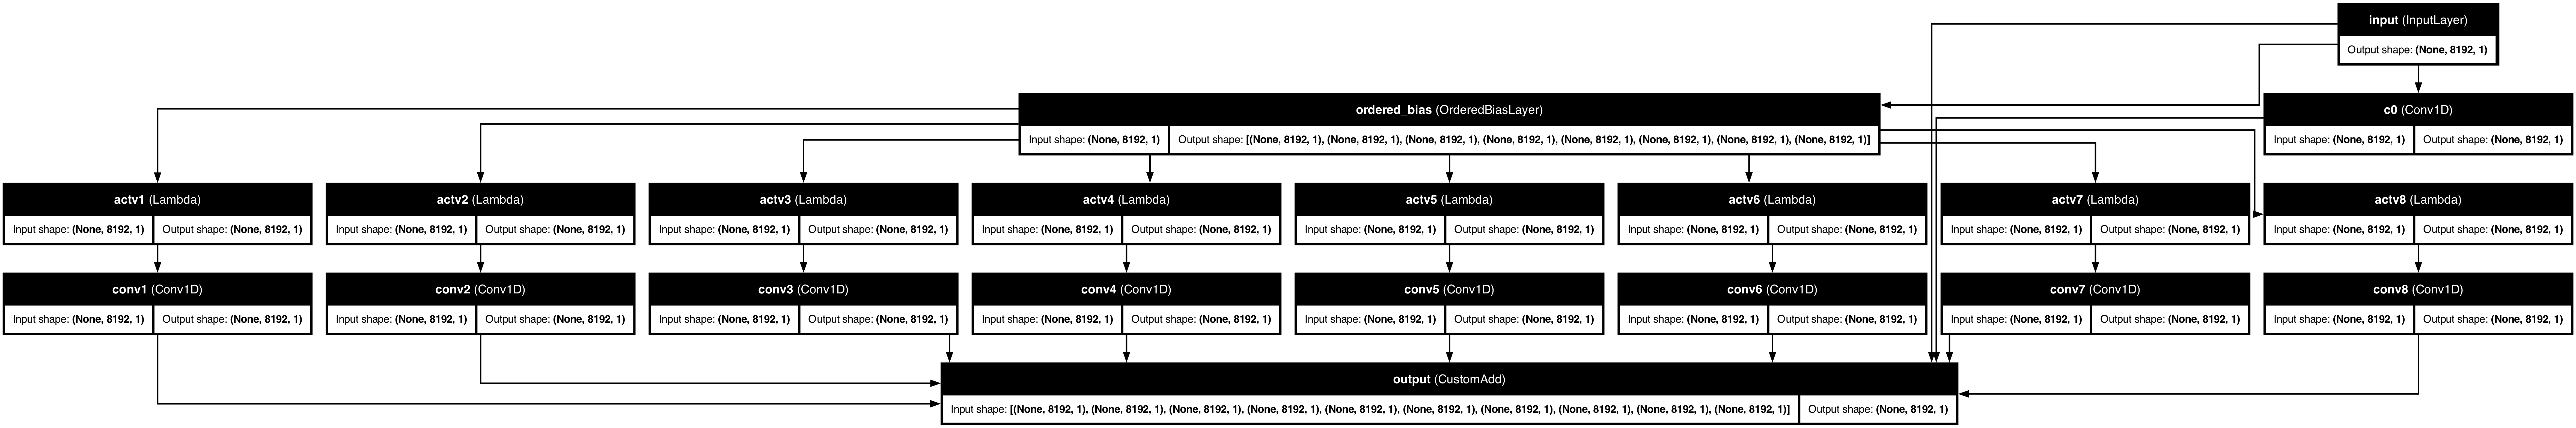

In [7]:
# =================================================================
# Build model
# =================================================================
input_shape = (len(V_test[0]), 1)
# Zeros init: all branch kernels start at 0  →  model output ≈ V at t=0
# (X-V correction has RMS ~0.01; GlorotUniform/HeNormal give norms ~1 → 77× off)
initializer = tf.keras.initializers.Zeros()

neural_network_model = define_block(
    input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
    k_initializer=initializer, outputs=1, bias_range=BIAS_RANGE
)
neural_network_model.summary()
tf.keras.utils.plot_model(neural_network_model, show_shapes=True, show_layer_names=True)


In [8]:
# =================================================================
# Training setup
# =================================================================
loss    = tf.keras.losses.LogCosh(reduction='sum_over_batch_size', name='mse')
metrics = [tf.keras.metrics.MeanAbsolutePercentageError(name='mape')]

checkpoint_val = tf.keras.callbacks.ModelCheckpoint(
    simulation_path + '.keras',
    monitor='val_loss', verbose=0, save_best_only=True, mode='min'
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=1e-8, patience=60,
    verbose=0, mode='auto', restore_best_weights=True
)
universal_print_callback = UniversalPrintCallback()

In [9]:
# =================================================================
# Train — NUM_RESTARTS independent random re-initializations
# =================================================================
loss_vector     = []
val_loss_vector = []
best_val        = np.inf
best_weights    = None

for j in range(NUM_RESTARTS):
    tf.keras.backend.clear_session()
    seed = 1 + j
    np.random.seed(seed)
    tf.random.set_seed(seed)

    initializer          = tf.keras.initializers.Zeros()
    neural_network_model = define_block(
        input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
        k_initializer=initializer, outputs=1, bias_range=BIAS_RANGE
    )
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999,
        epsilon=1e-10, amsgrad=False, name='Adam'
    )
    neural_network_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # The callback reprints this header on every epoch (survives clear_output)
    universal_print_callback.header = (
        f'Restart {j + 1}/{NUM_RESTARTS}  |  best val so far: {best_val:.2e}'
    )
    history = neural_network_model.fit(
        V, X,
        batch_size=BATCH_SIZE,
        epochs=NO_EPOCHS,
        verbose=0,
        validation_split=VALIDATION_SPLIT,
        shuffle=True,
        callbacks=[early_stopping, checkpoint_val, universal_print_callback]
    )

    loss_vector     = np.append(loss_vector, history.history['loss'])
    val_loss_vector = np.append(val_loss_vector, history.history['val_loss'])

    min_val = float(np.min(history.history['val_loss']))
    if min_val < best_val:
        best_val     = min_val
        best_weights = neural_network_model.get_weights()

# Restore best weights
if best_weights is not None:
    tf.keras.backend.clear_session()
    neural_network_model = define_block(
        input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
        k_initializer=tf.keras.initializers.Zeros(), outputs=1, bias_range=BIAS_RANGE
    )
    neural_network_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    neural_network_model.set_weights(best_weights)
    print(f'Done. Best val loss: {best_val:.2e}', flush=True)
    if SAVE_RESULTS:
        neural_network_model.save(f"{simulation_path}_best.keras")
        print(f'Model saved to {simulation_path}_best.keras')
    else:
        print('Model not saved (SAVE_RESULTS=False)')

Restart 10/10  |  best val so far: 1.71e-06
Epoch 60: Loss = 0.0000028, Validation Loss = 0.0000027
Done. Best val loss: 1.71e-06
Model not saved (SAVE_RESULTS=False)


In [10]:
# =================================================================
# Inspect learned parameters
# =================================================================

# ── Ordered biases ────────────────────────────────────────────────
# get_weights() returns [b1, b2, b3, ..., bN], each shape (1,)
# actual bias[k] = b1 + b2 + ... + b(k+1)  (cumulative sum)
ob_weights = neural_network_model.get_layer('ordered_bias').get_weights()
bk_vals = np.array([w[0] for w in ob_weights])   # raw increments, shape (N,)
b       = np.cumsum(bk_vals)                      # actual biases, shape (N,)

# ── Nonlinear branch Conv1D kernels ───────────────────────────────
w = []
for i in range(1, BRANCH_NUMBER + 1):
    kernel = neural_network_model.get_layer(f'conv{i}').get_weights()[0]  # (K,1,1)
    w.append(kernel.squeeze())
w = np.vstack(w)                                  # (BRANCH_NUMBER, kernel_size)

# ── Linear bypass (c0): FIR kernel + DC bias ─────────────────────
kernel_c0, bias_c0 = neural_network_model.get_layer('c0').get_weights()
c0       = kernel_c0.squeeze()
b0_bypass = float(bias_c0.squeeze())

print(f'Raw increments  [b1, b2, ..., bN]: {np.round(bk_vals, 5)}')
print(f'Actual biases   [cumsum]:          {np.round(b, 5)}')
print(f'\nNonlinear branch weights (rows=branches, cols=FIR taps):\n{w}')
print(f'\nLinear bypass:\n  FIR taps c0 = {c0}\n  DC offset b0 = {b0_bypass:.6f}')

Raw increments  [b1, b2, ..., bN]: [-0.92408  0.24796  0.12216  0.46458  0.5228   0.1985   0.27045  0.26034]
Actual biases   [cumsum]:          [-0.92408 -0.67612 -0.55395 -0.08938  0.43343  0.63192  0.90237  1.16272]

Nonlinear branch weights (rows=branches, cols=FIR taps):
[[-0.00188886 -0.01846733  0.00825499]
 [-0.0016036   0.04313154 -0.02052151]
 [ 0.00833369  0.04351462 -0.03295418]
 [ 0.01080742 -0.00660961 -0.0115089 ]
 [-0.00128342 -0.04569843  0.01092326]
 [ 0.00232494 -0.04246124  0.00896091]
 [-0.0007384   0.01801457 -0.00425095]
 [-0.00087154  0.01369837 -0.00274772]]

Linear bypass:
  FIR taps c0 = [ 0.01108551  0.12611908 -0.06562335]
  DC offset b0 = -0.000562


In [11]:
X_hat = neural_network_model.predict(V)[:,:,0]
print(np.shape(X), np.shape(V), np.shape(X_hat))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
(50, 8192) (50, 8192) (50, 8192)


In [12]:
# Predicting
X_hat_test = neural_network_model.predict(V_test)[:,:,0]
neural_network_model.evaluate(V_test, X_test);
print(np.shape(X_test), np.shape(V_test), np.shape(X_hat_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.5939e-06 - mape: 3.0676
(50, 8192) (50, 8192) (50, 8192)


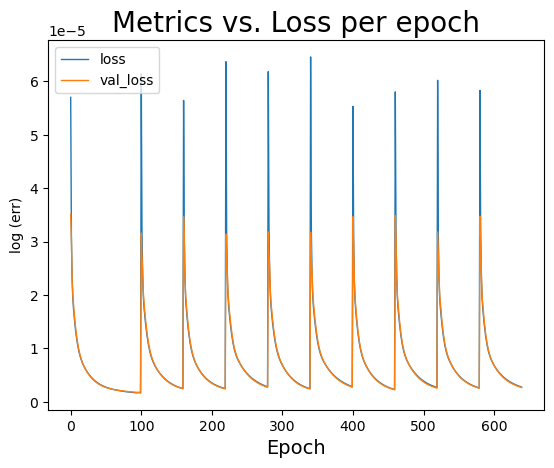

In [13]:
# Plot Accuracy Vs Lost
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
%matplotlib inline
# history.history.keys()
plt.plot(loss_vector,  label='loss', lw=1)
plt.plot(val_loss_vector,     label='val_loss', lw=1)  # fixed: full array, not scalar
# plt.yscale('log', nonposy='clip')
plt.xlabel('Epoch')
plt.ylabel('log (err)')
plt.title('Metrics vs. Loss per epoch', size=20)
plt.xlabel('Epoch', size=14)
plt.legend()
# plt.savefig('accuracy_cost.png')

In [14]:
# =================================================================
# Statistics
# =================================================================
print('-' * 20 + ' Train ' + '-' * 20)
SNR_array_X, SNR_array_V, SNR_array_X_hat = compute_statistics(
    X, V, X_hat,
    Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
    print_on_screen=True,
)
print('-' * 20 + ' Test  ' + '-' * 20)
SNR_X_test, SNR_V_test, SNR_X_hat_test = compute_statistics(
    X_test, V_test, X_hat_test,
    Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
    print_on_screen=True,
)

-------------------- Train --------------------
X:           ( 50 signals) SNDR: min: 64.96  mean: 67.14  max: 68.93
V:           ( 50 signals) SNDR: min: 28.75  mean: 30.5  max: 32.25
X_hat_MI:    ( 50 signals) SNDR: min: 43.77  mean: 45.08 max: 46.1
-------------------- Test  --------------------
X:           ( 50 signals) SNDR: min: 64.56  mean: 67.04  max: 68.87
V:           ( 50 signals) SNDR: min: 28.65  mean: 30.54  max: 31.74
X_hat_MI:    ( 50 signals) SNDR: min: 43.6  mean: 45.07 max: 45.95


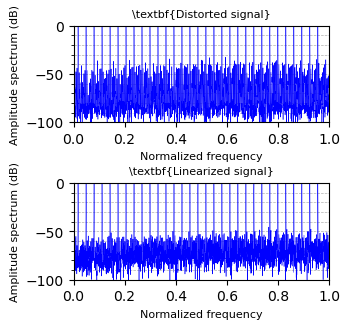

In [17]:
# =================================================================
# Plot (optional)
# =================================================================
if PLOTTING:
    title = ['Distorted signal', 'Linearized signal']
    signal_idx = 0
    SpectrumAnalyzer().plot_frequency_domain(
        [np.expand_dims(V_test[signal_idx], 0), np.expand_dims(X_hat_test[signal_idx], 0)],
        title,
        window_type='Blackmanharris',
        save_path=f"{simulation_path}/{folder_prefix}_{signal_idx}",
        save_fig=False,
    )